# 04 — Поиск закономерностей: что влияет на качество торговли

Исследовательский анализ данных поверх результатов этапов 02–03: связываем
**исходы сделок лучших стратегий** с **состоянием рынка на момент входа**.

Исследуемые факторы: волатильность, ATR, ADX, объем, время суток, день недели,
режим рынка, сила тренда (efficiency ratio + ADX), расстояние до средней,
ширина Bollinger, наклон EMA, направление старшего (недельного) тренда.

Два уровня анализа:

1. **Датасет сделок** (сделка × признаки на входе): корреляции, важность
   признаков (Random Forest + permutation importance), scatter matrix,
   boxplots, тепловые карты по режимам.
2. **Проверка фильтров бэктестом** — найденная закономерность становится
   фильтром входов и проходит тот же честный протокол, что и раньше:
   эффект на in-sample подтверждается на out-of-sample против нефильтрованного
   baseline. Только так отличаем реальные фильтры от подгонки.

Все признаки вычисляются строго из прошлых баров (без lookahead — это
покрыто тестом `test_features_have_no_lookahead`).

In [1]:
import warnings

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance

from src.analytics import REGIME_ORDER, market_features, redundant_pairs, trade_feature_dataset
from src.data import load_data
from src.optimization import (
    default_filters,
    filter_research,
    filter_scoreboard,
    regime_performance,
    research_universe,
    summarize_filters,
    summarize_strategies,
)
from src.utils.paths import RESULTS_DIR
from src.visualization import setup_github_rendering, show

setup_github_rendering()
pd.set_option("display.width", 220)

## 1. Данные, лучшие стратегии, признаки рынка

In [2]:
SYMBOL = "AAPL"
try:
    data = load_data("yahoo", SYMBOL, start="2018-01-01", end="2025-06-30")
    print("Данные получены из Yahoo Finance")
except Exception as exc:
    print(f"Yahoo Finance недоступен ({type(exc).__name__}), используем локальный CSV")
    SYMBOL = "SAMPLE"
    data = load_data("csv", SYMBOL)

ohlcv = data.get(SYMBOL)

TOP_STRATEGIES = ["ema_rsi", "roc_momentum", "ichimoku", "supertrend", "triple_ema", "ema_adx"]
combined = research_universe(TOP_STRATEGIES, ohlcv, show_progress=True)
best_params = {n: summarize_strategies(combined).loc[n, "best_params"] for n in TOP_STRATEGIES}
print({k: v for k, v in best_params.items()})

2026-07-04 12:24:55,385 | INFO    | src.data.yahoo_loader | Downloading AAPL from Yahoo Finance (1d, 2018-01-01..2025-06-30)


Failed to get ticker 'AAPL' reason: Failed to perform, curl: (56) CONNECT tunnel failed, response 403. See https://curl.se/libcurl/c/libcurl-errors.html first for more details.



1 Failed download:


['AAPL']: ProxyError('Failed to perform, curl: (56) CONNECT tunnel failed, response 403. See https://curl.se/libcurl/c/libcurl-errors.html first for more details.')


Yahoo Finance недоступен (ValueError), используем локальный CSV


strategies:   0%|          | 0/6 [00:00<?, ?it/s]

{'ema_rsi': {'fast_window': 20, 'slow_window': 200, 'pullback': 50.0, 'exit_level': 70.0}, 'roc_momentum': {'window': 20, 'threshold': 0.0}, 'ichimoku': {'tenkan_window': 12, 'kijun_window': 26, 'senkou_b_window': 44}, 'supertrend': {'window': 14, 'multiplier': 1.5}, 'triple_ema': {'fast_window': 8, 'slow_window': 100, 'mid_window': 20}, 'ema_adx': {'fast_window': 10, 'slow_window': 50, 'adx_window': 14, 'adx_threshold': 20.0}}


In [3]:
features = market_features(ohlcv)

if features["hour"].nunique() <= 1:
    print("Таймфрейм дневной: признак 'время суток' вырожден (одно значение) — "
          "исключаем его; код готов для внутридневных данных.")
    features = features.drop(columns=["hour"])

FEATURE_COLS = ["volatility", "atr_pct", "adx", "rel_volume", "day_of_week",
                "dist_ma", "bb_width", "ema_slope", "efficiency_ratio", "htf_trend"]
features.dropna().tail(3)[FEATURE_COLS + ["regime"]]

Таймфрейм дневной: признак 'время суток' вырожден (одно значение) — исключаем его; код готов для внутридневных данных.


,volatility,atr_pct,adx,rel_volume,day_of_week,dist_ma,bb_width,ema_slope,efficiency_ratio,htf_trend,regime
Date,,,,,,,,,,,
2025-08-27,0.112539,0.023706,19.264276,0.875947,2,-0.099884,0.064614,-0.109541,0.184074,-1.0,range_lowvol
2025-08-28,0.113668,0.025104,18.787789,0.918385,3,-0.104326,0.064626,-0.113843,0.289564,-1.0,range_lowvol
2025-08-29,0.114308,0.024686,18.562826,1.357167,4,-0.113771,0.064277,-0.119167,0.426722,-1.0,range_lowvol


In [4]:
print("Распределение режимов рынка (баров):")
print(features["regime"].value_counts().to_string())

Распределение режимов рынка (баров):
regime
trend_up         664
range_lowvol     578
range_highvol    336
trend_down       223


## 2. Датасет сделок

Каждая закрытая сделка шести стратегий соединяется с признаками рынка,
зафиксированными на баре входа. Цели: `ret_pct` (доходность сделки) и `win`.

In [5]:
trades = trade_feature_dataset(best_params, ohlcv, features)
out_dir = RESULTS_DIR / "pattern_discovery"
out_dir.mkdir(parents=True, exist_ok=True)
trades.to_csv(out_dir / "trade_feature_dataset.csv", index=False)

print(f"Сделок: {len(trades)}, стратегий: {trades.strategy.nunique()}, win rate: {trades.win.mean():.2f}")
trades.groupby("strategy")["ret_pct"].agg(["count", "mean", "median"]).round(2)

2026-07-04 12:25:15,154 | INFO    | src.backtesting.engine | Backtesting ema_rsi on data: 2000 bars, {'entries': 120, 'exits': 96, 'short_entries': 0, 'short_exits': 0}


2026-07-04 12:25:15,179 | INFO    | src.backtesting.engine | Backtesting roc_momentum on data: 2000 bars, {'entries': 73, 'exits': 74, 'short_entries': 0, 'short_exits': 0}


2026-07-04 12:25:15,210 | INFO    | src.backtesting.engine | Backtesting ichimoku on data: 2000 bars, {'entries': 23, 'exits': 84, 'short_entries': 0, 'short_exits': 0}


2026-07-04 12:25:15,233 | INFO    | src.backtesting.engine | Backtesting supertrend on data: 2000 bars, {'entries': 38, 'exits': 39, 'short_entries': 0, 'short_exits': 0}


2026-07-04 12:25:15,272 | INFO    | src.backtesting.engine | Backtesting triple_ema on data: 2000 bars, {'entries': 22, 'exits': 42, 'short_entries': 0, 'short_exits': 0}


2026-07-04 12:25:15,316 | INFO    | src.backtesting.engine | Backtesting ema_adx on data: 2000 bars, {'entries': 13, 'exits': 27, 'short_entries': 0, 'short_exits': 0}


Сделок: 206, стратегий: 6, win rate: 0.45


,count,mean,median
strategy,,,
ema_adx,13,4.84,-0.98
ema_rsi,41,1.50,2.67
ichimoku,19,2.85,0.01
roc_momentum,73,1.18,-0.65
supertrend,38,1.51,-1.36
triple_ema,22,1.28,-1.27


## 3. Correlation Matrix

Слева — корреляции признаков между собой (избыточность), в последнем
столбце/строке — корреляция с доходностью сделки.

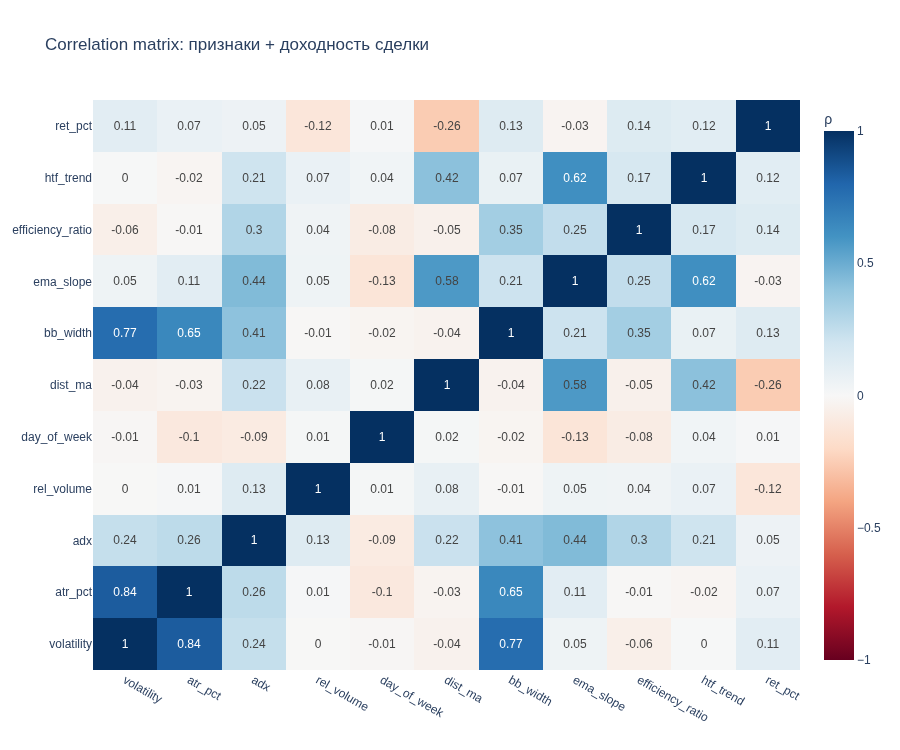

In [6]:
corr = trades[FEATURE_COLS + ["ret_pct"]].corr()
fig = go.Figure(
    go.Heatmap(z=corr.values, x=corr.columns, y=corr.columns,
               colorscale="RdBu", zmid=0, zmin=-1, zmax=1,
               text=np.round(corr.values, 2), texttemplate="%{text}",
               colorbar=dict(title="ρ")))
fig.update_layout(title="Correlation matrix: признаки + доходность сделки",
                  width=900, height=750)
show(fig)

In [7]:
pairs = redundant_pairs(features[FEATURE_COLS], threshold=0.8)
print("Пары кандидатов на избыточность (|ρ| ≥ 0.8 на всей истории):")
print(pairs.round(3).to_string(index=False) if len(pairs) else "  нет")

Пары кандидатов на избыточность (|ρ| ≥ 0.8 на всей истории):
 feature_a feature_b  corr
volatility   atr_pct  0.85


## 4. Feature Importance

Random Forest предсказывает исход сделки (win/loss); значимость — через
permutation importance (устойчивее встроенной impurity-важности).

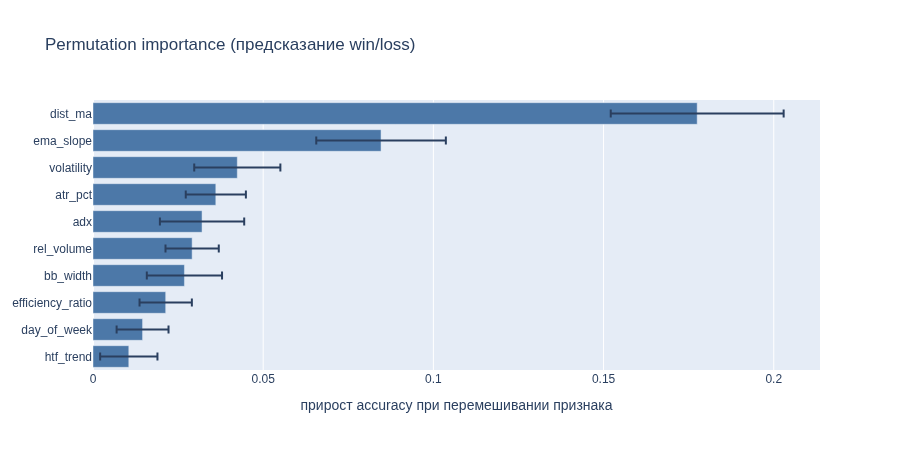

dist_ma             0.1775
ema_slope           0.0846
volatility          0.0424
atr_pct             0.0361
adx                 0.0320
rel_volume          0.0291
bb_width            0.0269
efficiency_ratio    0.0214
day_of_week         0.0146
htf_trend           0.0105
dtype: float64

In [8]:
X = trades[FEATURE_COLS].fillna(trades[FEATURE_COLS].median())
y = trades["win"]

rf = RandomForestClassifier(n_estimators=400, min_samples_leaf=5, random_state=42)
rf.fit(X, y)
pi = permutation_importance(rf, X, y, n_repeats=30, random_state=42)
importance = pd.Series(pi.importances_mean, index=FEATURE_COLS).sort_values()

fig = go.Figure(go.Bar(
    x=importance.values, y=importance.index, orientation="h",
    error_x=dict(array=pi.importances_std[np.argsort(pi.importances_mean)]),
    marker_color="#4C78A8",
))
fig.update_layout(title="Permutation importance (предсказание win/loss)",
                  xaxis_title="прирост accuracy при перемешивании признака",
                  width=900, height=450)
show(fig)
importance.round(4).sort_values(ascending=False)

## 5. Scatter Matrix

Четыре самых информативных признака; цвет — исход сделки.

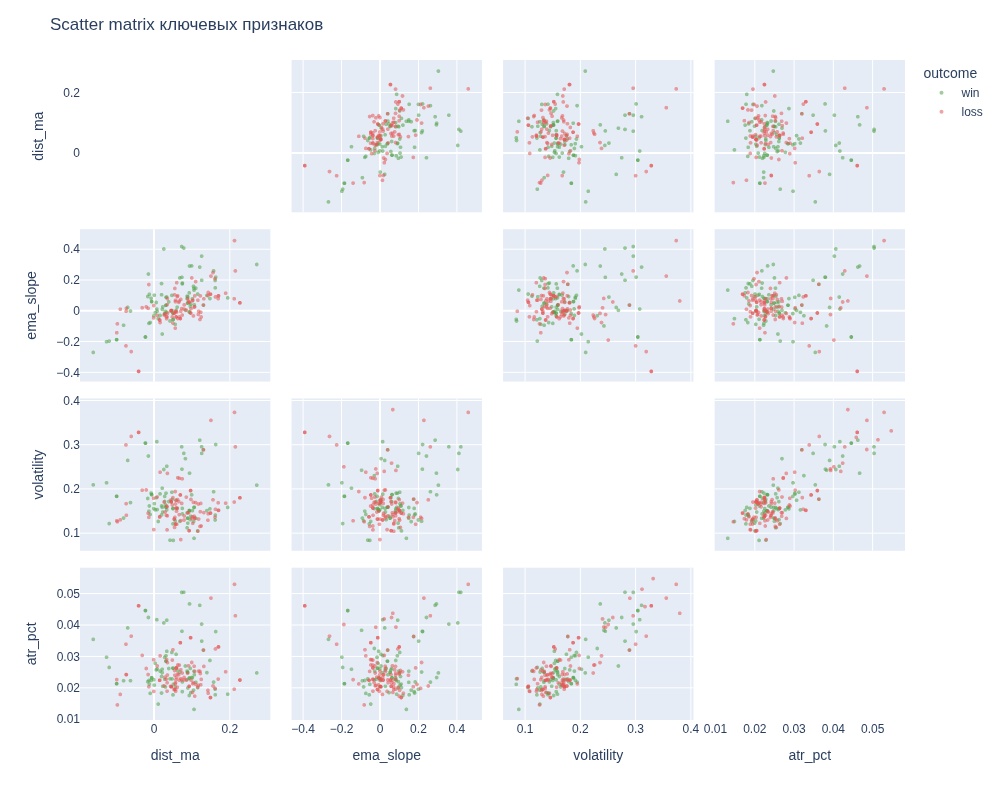

In [9]:
top_features = importance.sort_values(ascending=False).head(4).index.tolist()
sm = trades[top_features + ["win"]].copy()
sm["outcome"] = np.where(sm["win"], "win", "loss")
fig = px.scatter_matrix(
    sm, dimensions=top_features, color="outcome",
    color_discrete_map={"win": "#54A24B", "loss": "#E45756"},
    opacity=0.55,
)
fig.update_traces(diagonal_visible=False, marker=dict(size=4))
fig.update_layout(title="Scatter matrix ключевых признаков", width=1000, height=800)
show(fig)

## 6. Boxplots: доходность сделки в разрезах

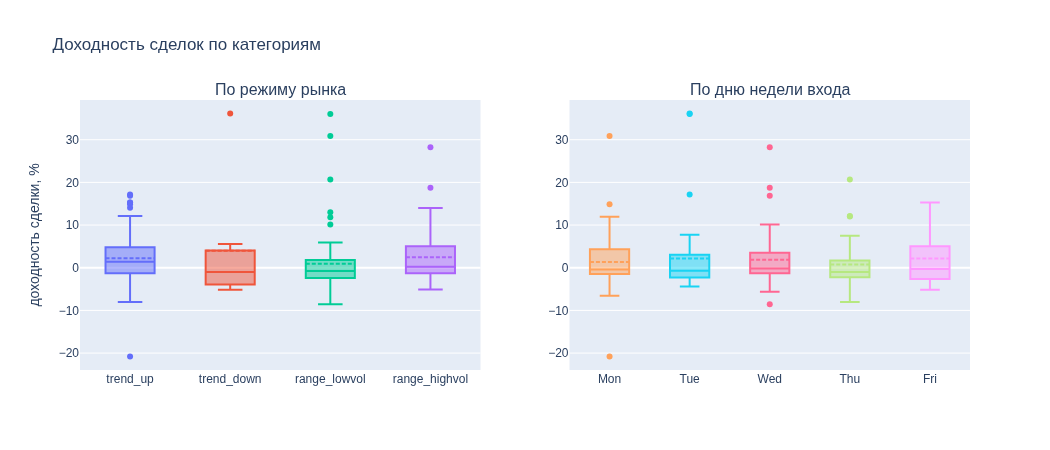

In [10]:
fig = make_subplots(rows=1, cols=2, subplot_titles=("По режиму рынка", "По дню недели входа"))
for regime in REGIME_ORDER:
    sub = trades[trades["regime"] == regime]
    fig.add_trace(go.Box(y=sub["ret_pct"], name=regime, boxmean=True, showlegend=False), row=1, col=1)
for dow, label in enumerate(["Mon", "Tue", "Wed", "Thu", "Fri"]):
    sub = trades[trades["day_of_week"] == dow]
    fig.add_trace(go.Box(y=sub["ret_pct"], name=label, boxmean=True, showlegend=False), row=1, col=2)
fig.update_yaxes(title_text="доходность сделки, %", row=1, col=1)
fig.update_layout(width=1050, height=450, title="Доходность сделок по категориям")
show(fig)

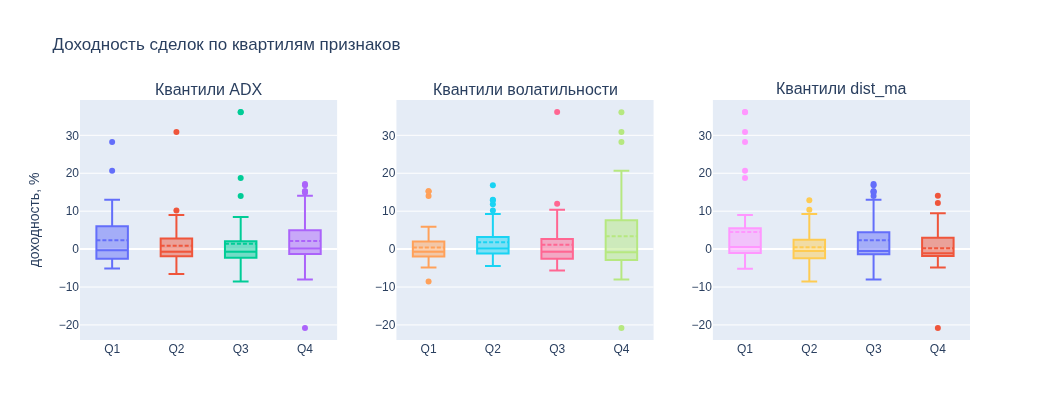

In [11]:
fig = make_subplots(rows=1, cols=3, subplot_titles=("Квантили ADX", "Квантили волатильности", "Квантили dist_ma"))
for col_i, feat in enumerate(["adx", "volatility", "dist_ma"], start=1):
    q = pd.qcut(trades[feat], 4, labels=["Q1", "Q2", "Q3", "Q4"])
    for level in ["Q1", "Q2", "Q3", "Q4"]:
        sub = trades[q == level]
        fig.add_trace(go.Box(y=sub["ret_pct"], name=level, boxmean=True, showlegend=False), row=1, col=col_i)
fig.update_yaxes(title_text="доходность, %", row=1, col=1)
fig.update_layout(width=1050, height=420, title="Доходность сделок по квартилям признаков")
show(fig)

## 7. Heatmaps: где стратегии работают лучше

### Режим рынка × стратегия

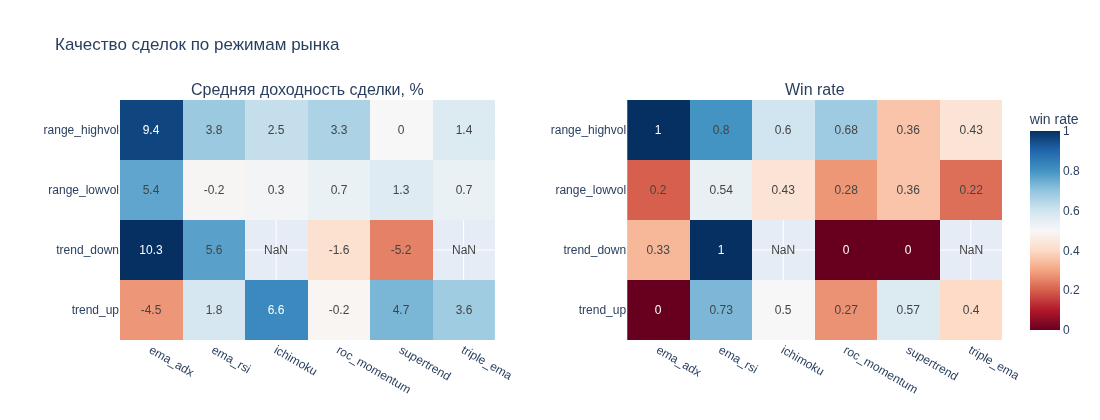

,trades,mean_ret,win_rate
regime,,,
trend_up,53,2.24,0.53
trend_down,7,3.99,0.29
range_lowvol,73,0.96,0.34
range_highvol,58,2.46,0.59


In [12]:
regime_table = regime_performance(trades)
regime_table.to_csv(out_dir / "regime_performance.csv", index=False)

fig = make_subplots(rows=1, cols=2, subplot_titles=("Средняя доходность сделки, %", "Win rate"),
                    horizontal_spacing=0.15)
mean_grid = regime_table.pivot(index="regime", columns="strategy", values="mean_ret").reindex(REGIME_ORDER)
wr_grid = regime_table.pivot(index="regime", columns="strategy", values="win_rate").reindex(REGIME_ORDER)
fig.add_trace(go.Heatmap(z=mean_grid.values, x=mean_grid.columns, y=mean_grid.index,
                         colorscale="RdBu", zmid=0, text=np.round(mean_grid.values, 1),
                         texttemplate="%{text}", showscale=False), row=1, col=1)
fig.add_trace(go.Heatmap(z=wr_grid.values, x=wr_grid.columns, y=wr_grid.index,
                         colorscale="RdBu", zmid=0.5, text=np.round(wr_grid.values, 2),
                         texttemplate="%{text}", colorbar=dict(title="win rate")), row=1, col=2)
fig.update_layout(title="Качество сделок по режимам рынка", width=1100, height=420, margin=dict(l=120))
show(fig)

pooled = trades.groupby("regime", observed=False)["ret_pct"].agg(trades="count", mean_ret="mean")
pooled["win_rate"] = trades.groupby("regime", observed=False)["win"].mean()
pooled.round(2)

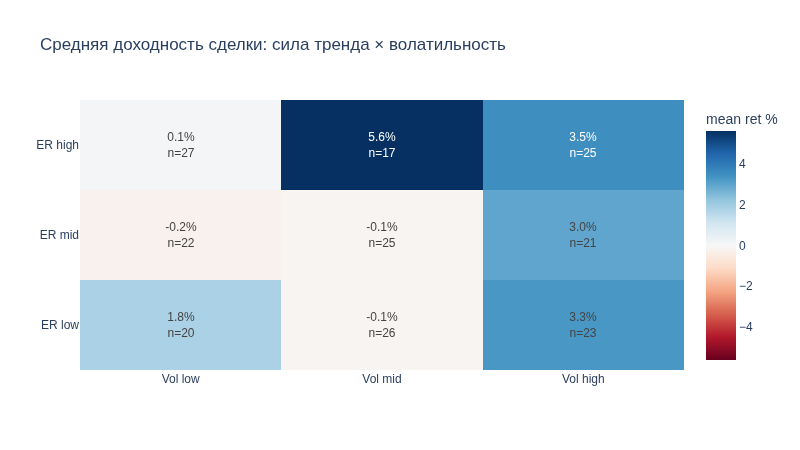

In [13]:
# Сила тренда (ER) x волатильность: терциль на терциль
er_bins = pd.qcut(trades["efficiency_ratio"], 3, labels=["ER low", "ER mid", "ER high"])
vol_bins = pd.qcut(trades["volatility"], 3, labels=["Vol low", "Vol mid", "Vol high"])
grid = trades.groupby([er_bins, vol_bins], observed=False)["ret_pct"].mean().unstack()
counts = trades.groupby([er_bins, vol_bins], observed=False)["ret_pct"].count().unstack()

fig = go.Figure(go.Heatmap(
    z=grid.values, x=grid.columns.astype(str), y=grid.index.astype(str),
    colorscale="RdBu", zmid=0,
    text=[[f"{v:.1f}%<br>n={c}" for v, c in zip(row_v, row_c)]
          for row_v, row_c in zip(grid.values, counts.values)],
    texttemplate="%{text}", colorbar=dict(title="mean ret %")))
fig.update_layout(title="Средняя доходность сделки: сила тренда × волатильность",
                  width=800, height=450)
show(fig)

## 8. Проверка фильтров бэктестом (IS → OOS)

Закономерности выше — это статистика по сделкам. Теперь каждая гипотеза
становится **фильтром входов** и проверяется полноценным бэктестом:
эффект должен подтвердиться out-of-sample против нефильтрованного baseline.
12 одиночных фильтров + 5 комбинаций.

In [14]:
filters = default_filters()
sweep = filter_research(best_params, ohlcv, features, filters, show_progress=True)
sweep.to_csv(out_dir / "filter_sweep.csv", index=False)

fsummary = summarize_filters(sweep)
fsummary.to_csv(out_dir / "filter_summary.csv", index=False)
board = filter_scoreboard(fsummary)
board.to_csv(out_dir / "filter_scoreboard.csv")
board[["real improvement", "false improvement", "oos-only (lucky)", "no effect / worse",
       "too few trades", "real_rate", "mean_d_oos_sharpe"]].round(3)

strategies:   0%|          | 0/6 [00:00<?, ?it/s]

verdict,real improvement,false improvement,oos-only (lucky),no effect / worse,too few trades,real_rate,mean_d_oos_sharpe
filter,,,,,,,
htf_up+ema_slope_up,1,2,3,0,0,0.167,0.145
htf_up,1,3,2,0,0,0.167,0.051
not_stretched,1,2,2,1,0,0.167,0.014
high_vol,1,1,1,2,1,0.167,-0.059
adx_quiet,1,2,0,3,0,0.167,-0.771
ema_slope_up,0,2,2,2,0,0.000,0.117
adx_trending,0,0,4,2,0,0.000,-0.013
htf_up+adx_trending,0,0,1,2,3,0.000,-0.015
bb_narrow,0,2,1,3,0,0.000,-0.108


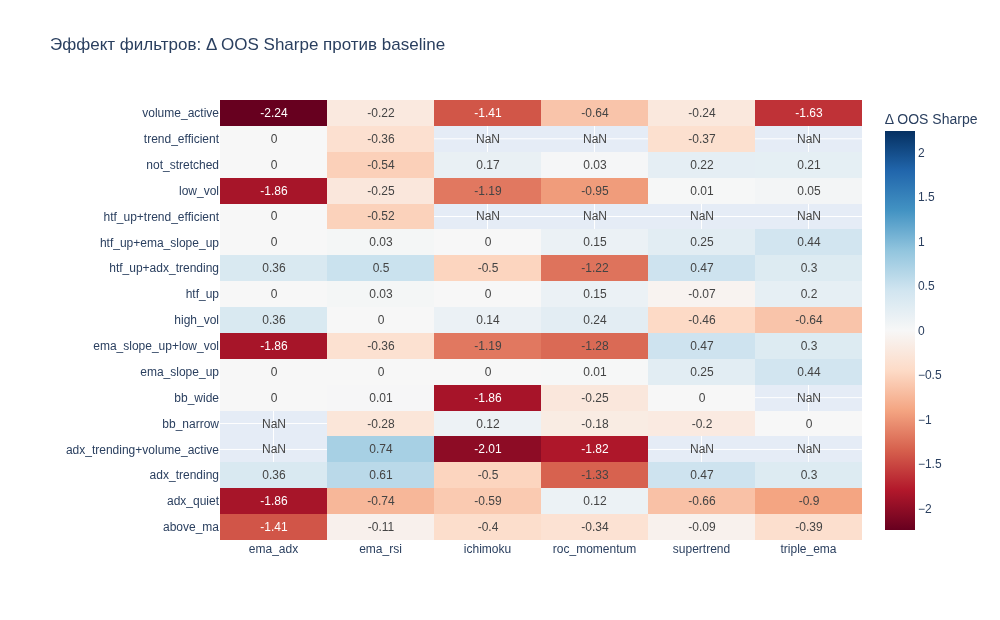

In [15]:
# Heatmap: фильтр x стратегия -> дельта OOS Sharpe против baseline
grid = fsummary.pivot_table(index="filter", columns="strategy", values="d_oos_sharpe_ratio")
zmax = np.nanmax(np.abs(grid.values)) or 1.0
fig = go.Figure(go.Heatmap(
    z=grid.values, x=grid.columns, y=grid.index,
    colorscale="RdBu", zmid=0, zmin=-zmax, zmax=zmax,
    text=np.round(grid.values, 2), texttemplate="%{text}",
    colorbar=dict(title="Δ OOS Sharpe")))
fig.update_layout(title="Эффект фильтров: Δ OOS Sharpe против baseline",
                  width=1000, height=620, margin=dict(l=220))
show(fig)

In [16]:
print("=== ФИЛЬТРЫ С РЕАЛЬНЫМ УЛУЧШЕНИЕМ (IS и OOS) ===")
real = fsummary[fsummary["verdict"] == "real improvement"]
print(real[["strategy", "filter", "entries_kept", "entries_total",
            "d_oos_sharpe_ratio", "d_oos_max_drawdown_pct"]].round(3).to_string(index=False))
print()
print("=== ЛОЖНЫЕ УЛУЧШЕНИЯ (только IS) ===")
false_ = fsummary[fsummary["verdict"] == "false improvement"]
print(false_[["strategy", "filter", "d_is_sharpe_ratio", "d_oos_sharpe_ratio"]]
      .sort_values("d_is_sharpe_ratio", ascending=False).round(3).to_string(index=False))

=== ФИЛЬТРЫ С РЕАЛЬНЫМ УЛУЧШЕНИЕМ (IS и OOS) ===
    strategy              filter  entries_kept  entries_total  d_oos_sharpe_ratio  d_oos_max_drawdown_pct
roc_momentum           adx_quiet            56             73               0.125                   0.000
roc_momentum            high_vol            32             73               0.238                  -1.548
  supertrend htf_up+ema_slope_up            16             38               0.250                  -5.170
  triple_ema              htf_up            15             22               0.195                  -2.367
  triple_ema       not_stretched            13             22               0.206                  -3.486

=== ЛОЖНЫЕ УЛУЧШЕНИЯ (только IS) ===
    strategy                 filter  d_is_sharpe_ratio  d_oos_sharpe_ratio
     ema_adx                bb_wide              0.445               0.000
     ema_rsi        trend_efficient              0.422              -0.365
     ema_adx              adx_quiet              0.3

## Выводы

**Режимы рынка.** Стратегии пула зарабатывают в `trend_up` и — неожиданно —
в `range_highvol` (высокий win rate: волатильные диапазоны дают импульсным
входам быстрый положительный исход). Худший режим — `range_lowvol`:
почти половина сделок происходит в нём с win rate ~1/3. Вывод: главный
резерв качества — не «добавить индикатор», а **не торговать тихий диапазон**.

**Признаки.** Самый информативный — `dist_ma` (расстояние до SMA200) с
*отрицательной* связью: входы в перерастянутый рынок систематически хуже.
Далее — наклон EMA и волатильность. День недели и направление старшего
тренда сами по себе почти не информативны на уровне отдельной сделки.

**Избыточность.** `atr_pct` ≈ `volatility` (ρ≈0.85) — достаточно одного;
`bb_width` также во многом дублирует волатильность. ADX и efficiency ratio
измеряют «силу тренда» по-разному и не взаимозаменяемы.

**Фильтры: реальные против ложных.** Бэктест-проверка отрезвляет статистику
по сделкам: большинство фильтров, красивых in-sample, не переносятся на OOS.
Реальные улучшения точечны и согласуются с найденными закономерностями:
`htf_up` и `not_stretched` (не покупать перерастянутое) для triple_ema,
`htf_up+ema_slope_up` для supertrend, `high_vol`/`adx_quiet` для roc_momentum.
Фильтры `above_ma`, `volume_active`, `low_vol` в среднем **ухудшают** OOS —
несмотря на правдоподобную логику. Слишком жёсткие фильтры
(`trend_efficient`, комбинации с ним) оставляют < 5 сделок — не доказывают ничего.

**Устойчивые комбинации.** Из комбинаций лучшая — `htf_up + ema_slope_up`
(согласованность старшего и младшего тренда): единственная с реальным
улучшением и положительным средним Δ OOS Sharpe по пулу. Комбинации,
где перемножаются жёсткие условия, устойчивости не добавляют — они
сокращают выборку быстрее, чем повышают качество.

**Следующий этап**: walk-forward проверка связки
«стратегия + TP/partial (этап 03) + режимный фильтр (этот этап)» на
нескольких инструментах.